# **A. Library dan Data**

## **1. Package**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
import os

## **2. Parameter**

In [ ]:
INPUT_FN = "/content/Data Skripsi.xlsx"
SHEET_NAME = 0
OUTPUT_DIR = "."
DROP_INITIAL_ROWS = True

## **3. Data**

In [ ]:
df0 = pd.read_excel(INPUT_FN, sheet_name=SHEET_NAME)
print("Columns (raw):", list(df0.columns))
display(df0.head(8))

Columns (raw): ['Tanggal', 'Kurs', 'Inflasi', 'Wisatawan']


,Tanggal,Kurs,Inflasi,Wisatawan
0,2000-01-01,7268.5996,1.32,356090
1,2000-02-01,7417.0000,0.07,397548
2,2000-03-01,7465.0000,-0.45,413502
3,2000-04-01,7760.0000,0.56,408239
4,2000-05-01,8351.0000,0.84,370474
5,2000-06-01,8532.5000,0.50,424277
6,2000-07-01,9122.0000,1.28,464278
7,2000-08-01,8434.2998,0.51,455967


## **4. Deteksi Kolom Tanggal**

In [ ]:
def detect_date_col(df):
    for c in df.columns:
        parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)
        if parsed.notna().sum() >= 0.5 * len(parsed):
            return c
    return None

date_col = detect_date_col(df0) or df0.columns[0]
print("Detected date column:", date_col)

Detected date column: Tanggal


/tmp/ipykernel_251/2743099615.py:3: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(df[c], errors='coerce', infer_datetime_format=True)


## **5. Normalisasi Format Indeks Tanggal**

In [ ]:
df = df0.copy()
df[date_col] = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)
df['period'] = df[date_col].dt.to_period("M").dt.to_timestamp()
df.set_index('period', inplace=True)
df.sort_index(inplace=True)
df.drop(columns=[date_col], inplace=True, errors='ignore')

/tmp/ipykernel_251/1792981048.py:2: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce', infer_datetime_format=True)


## **6. Normalisasi Nama Kolom**

In [ ]:
df.rename(columns=lambda s: str(s).strip().lower().replace(" ", "_"), inplace=True)
print("Normalized columns:", list(df.columns))

Normalized columns: ['kurs', 'inflasi', 'wisatawan']


## **7. Skewness dan Missing Value**

In [ ]:
skew_tbl = df.skew().rename("skew")
missing_pct = (df.isna().sum()/len(df)*100).rename("missing_pct")
extra = pd.concat([skew_tbl, missing_pct], axis=1)
print("\nSkewness & missing %:")
display(extra)


Skewness & missing %:


,skew,missing_pct
kurs,0.293544,0.0
inflasi,5.579669,0.0
wisatawan,0.575001,0.0


# **B. Visualisasi**

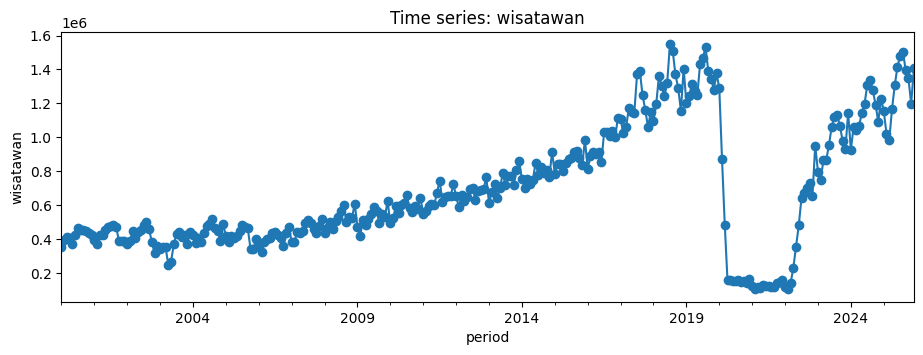

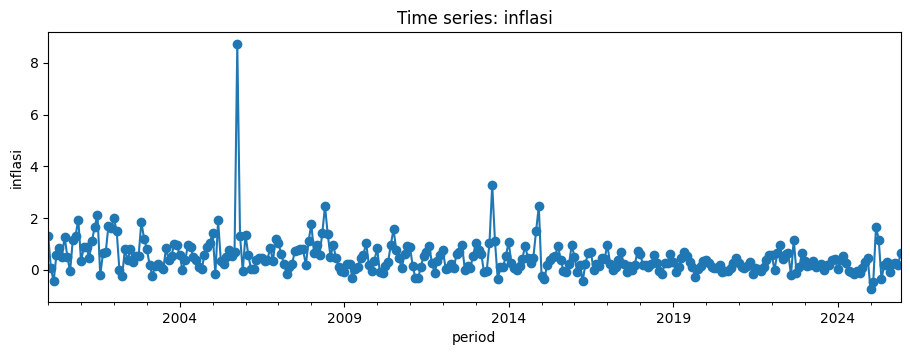

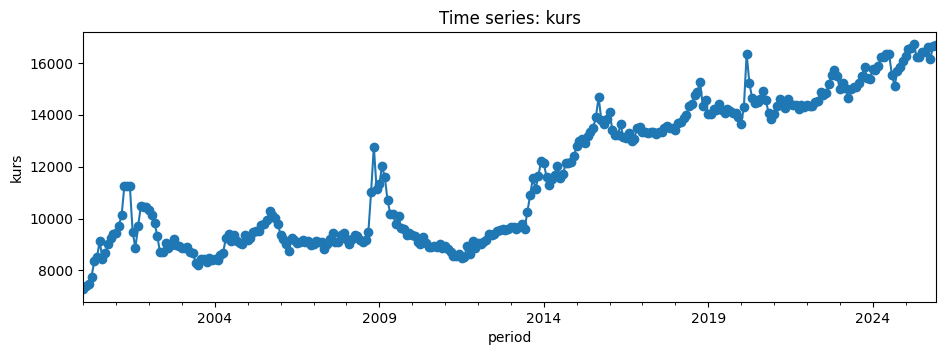

In [ ]:
plt.rcParams['figure.figsize'] = (11,3.5)
for col in ['wisatawan','inflasi','kurs']:
    if col in df.columns:
        ax = df[col].plot(marker='o', title=f"Time series: {col}")
        ax.set_ylabel(col)
        plt.show()

# **C. Feature Engineering dan Handling Missing**

## **1. Feature Engineering**

In [ ]:
# Wisatawan
df['log1p_wisatawan'] = np.log1p(df['wisatawan'].astype(float))
df['lag1_wisatawan'] = df['log1p_wisatawan'].shift(1)
df['lag12_wisatawan'] = df['log1p_wisatawan'].shift(12)
df['mom_wisatawan'] = df['wisatawan'].pct_change(1)

# Inflasi
df['lag1_inflasi'] = df['inflasi'].shift(1)
df['lag6_inflasi'] = df['inflasi'].shift(6)

# Kurs
df['fx_log'] = np.log(df['kurs'].astype(float))
df['fx_return'] = df['fx_log'].diff()
df['lag1_fx_return'] = df['fx_return'].shift(1)
df['lag2_fx_return'] = df['fx_return'].shift(2)

# Musiman (siklus bulan)
df['monthnum'] = df.index.month
df['sin_month'] = np.sin(2*np.pi*df['monthnum']/12)
df['cos_month'] = np.cos(2*np.pi*df['monthnum']/12)

## **2. Missing Value dan Penanganan**

In [ ]:
feature_cols = [
    'log1p_wisatawan','lag1_wisatawan','lag12_wisatawan','mom_wisatawan',
    'inflasi','lag1_inflasi','lag6_inflasi',
    'fx_return','lag1_fx_return','lag2_fx_return',
    'sin_month','cos_month'
]
print("\nMissing counts per feature (before imputasi):")
print(df[feature_cols].isna().sum())


Missing counts per feature (before imputasi):
log1p_wisatawan     0
lag1_wisatawan      1
lag12_wisatawan    12
mom_wisatawan       1
inflasi             0
lag1_inflasi        1
lag6_inflasi        6
fx_return           1
lag1_fx_return      2
lag2_fx_return      3
sin_month           0
cos_month           0
dtype: int64


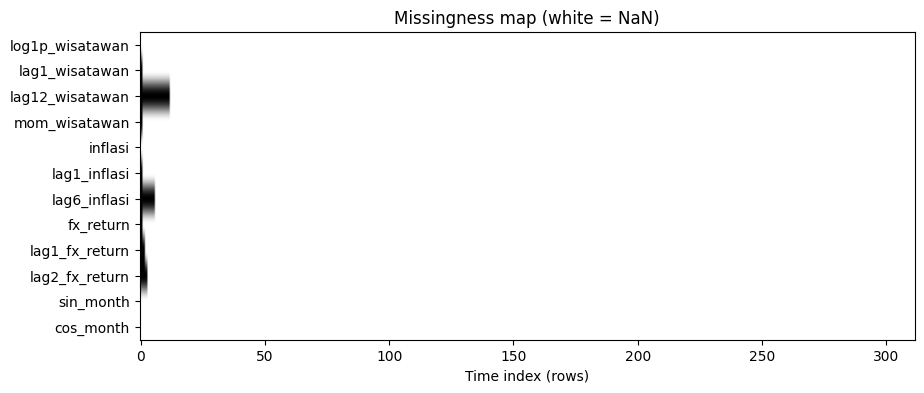

In [ ]:
plt.figure(figsize=(10,4))
plt.imshow(df[feature_cols].isna().T, aspect="auto", cmap="gray_r")
plt.yticks(range(len(feature_cols)), feature_cols)
plt.xlabel("Time index (rows)")
plt.title("Missingness map (white = NaN)")
plt.show()

In [ ]:
df_impute = df[feature_cols].copy()
df_flags = pd.DataFrame(index=df.index)
df_flags['imputed_any'] = False

SMALL_GAP_THRESHOLD = 3
for col in feature_cols:
    isna = df_impute[col].isna()
    if isna.any():
        runs = []
        start = None
        for i, val in enumerate(isna):
            if val and start is None:
                start = i
            if not val and start is not None:
                runs.append((start, i-1))
                start = None
        if start is not None:
            runs.append((start, len(isna)-1))
        for r in runs:
            length = r[1]-r[0]+1
            idx_range = df_impute.index[r[0]:r[1]+1]
            if length <= SMALL_GAP_THRESHOLD:
                df_impute[col] = df_impute[col].interpolate(method="time")
                df_flags.loc[idx_range,'imputed_any'] = True
            else:
                df_flags.loc[idx_range,'imputed_any'] = True
                df_flags.loc[idx_range,f'imputed_long_{col}'] = True

In [ ]:
if DROP_INITIAL_ROWS:
    df_ready = df_impute.iloc[12:].copy()
    flags_ready = df_flags.iloc[12:].copy()
else:
    df_ready = df_impute.copy()
    flags_ready = df_flags.copy()

In [ ]:
df_ready['mom_wisatawan'] = df_ready['mom_wisatawan'].clip(-0.99, 10)

print("\nRows in final df_ready:", len(df_ready))
print("Missing (final):")
print(df_ready.isna().sum())


Rows in final df_ready: 300
Missing (final):
log1p_wisatawan    0
lag1_wisatawan     0
lag12_wisatawan    0
mom_wisatawan      0
inflasi            0
lag1_inflasi       0
lag6_inflasi       0
fx_return          0
lag1_fx_return     0
lag2_fx_return     0
sin_month          0
cos_month          0
dtype: int64


In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_ready.to_csv(os.path.join(OUTPUT_DIR, "features_ready_for_copod.csv"))
flags_ready.to_csv(os.path.join(OUTPUT_DIR, "features_impute_flags.csv"))

## **3. Fitur Untuk COPOD dan Validasi**

In [ ]:
FN_FEATURES = "features_ready_for_copod.csv"
FN_FLAGS = "features_impute_flags.csv"

X = pd.read_csv(FN_FEATURES, parse_dates=[0], index_col=0)
print("Loaded features shape:", X.shape)
print("Index dtype:", X.index.dtype)
print("Date range:", X.index.min(), "to", X.index.max())

Loaded features shape: (300, 12)
Index dtype: datetime64[ns]
Date range: 2001-01-01 00:00:00 to 2025-12-01 00:00:00


In [ ]:
expected = [
    'log1p_wisatawan','lag1_wisatawan','lag12_wisatawan','mom_wisatawan',
    'inflasi', 'lag1_inflasi','lag6_inflasi',
    'fx_return','lag1_fx_return','lag2_fx_return',
    'sin_month','cos_month'
]
presence = {f: (f in X.columns) for f in expected}
print("\nExpected features present:")
for k,v in presence.items():
    print(f" - {k}: {v}")

if 'inflation_yoy' not in X.columns and 'inflasi' in X.columns:
    print("\nNote: found 'inflasi' — consider renaming to 'inflation_yoy'.")


Expected features present:
 - log1p_wisatawan: True
 - lag1_wisatawan: True
 - lag12_wisatawan: True
 - mom_wisatawan: True
 - inflasi: True
 - lag1_inflasi: True
 - lag6_inflasi: True
 - fx_return: True
 - lag1_fx_return: True
 - lag2_fx_return: True
 - sin_month: True
 - cos_month: True

Note: found 'inflasi' — consider renaming to 'inflation_yoy'.


In [ ]:
miss_tbl = pd.concat([
    X.isna().sum().rename("missing_count"),
    (X.isna().sum()/len(X)*100).rename("missing_pct")
], axis=1)
print("\nMissing summary:")
display(miss_tbl)

inf_cols = [c for c in X.columns if np.isinf(pd.to_numeric(X[c], errors='coerce')).any()]
print("Columns with inf:", inf_cols)


Missing summary:


,missing_count,missing_pct
log1p_wisatawan,0,0.0
lag1_wisatawan,0,0.0
lag12_wisatawan,0,0.0
mom_wisatawan,0,0.0
inflasi,0,0.0
lag1_inflasi,0,0.0
lag6_inflasi,0,0.0
fx_return,0,0.0
lag1_fx_return,0,0.0
lag2_fx_return,0,0.0


Columns with inf: []


In [ ]:
print("\nDuplicate index rows:", X.index.duplicated().sum())

if os.path.exists(FN_FLAGS):
    flags = pd.read_csv(FN_FLAGS, parse_dates=[0], index_col=0)
    print("Flags summary:")
    display(flags.sum(numeric_only=True))
else:
    print("No flags file found.")


Duplicate index rows: 0
Flags summary:


,0
imputed_any,0.0
imputed_long_lag12_wisatawan,0.0
imputed_long_lag6_inflasi,0.0


# **D. Fit & Score COPOD**

In [ ]:
!pip install pyod
from pyod.models.copod import COPOD

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.8/219.8 kB 8.0 MB/s eta 0:00:00


## **1. Parameter dan Load Data Fitur**

In [ ]:
FEATURES_CSV = "features_ready_for_copod.csv"
FLAGS_CSV = "features_impute_flags.csv"
TRAIN_END = "2019-12-01"
PERCENTILE_THRESH = [97.5, 99.0, 99.5, 99.9]
TOP_N = 15
DROP_NA_BEFORE_FIT = True
SAVE_PREFIX = "copod_results"

In [ ]:
X = pd.read_csv(FEATURES_CSV, parse_dates=[0], index_col=0)
feature_cols = [
    'log1p_wisatawan','lag1_wisatawan','lag12_wisatawan','mom_wisatawan',
    'inflasi','lag1_inflasi','lag6_inflasi',
    'fx_return','lag1_fx_return','lag2_fx_return',
    'sin_month','cos_month'
]
X = X[feature_cols].dropna()

## **2. Fit Model COPOD**

In [ ]:
train_end = pd.to_datetime(TRAIN_END)
X_train = X.loc[:train_end]
print("Train rows:", len(X_train), " | Total:", len(X))

Train rows: 228  | Total: 300


In [ ]:
skew_tbl = X_train.skew().rename("skew")
print(skew_tbl)

log1p_wisatawan    4.274329e-01
lag1_wisatawan     4.391039e-01
lag12_wisatawan    5.441505e-01
mom_wisatawan      1.393690e-02
inflasi            5.679862e+00
lag1_inflasi       5.560228e+00
lag6_inflasi       5.479643e+00
fx_return         -1.836816e-03
lag1_fx_return    -1.177280e-02
lag2_fx_return    -2.004225e-02
sin_month          0.000000e+00
cos_month         -2.661911e-16
Name: skew, dtype: float64


In [ ]:
clf = COPOD()
clf.fit(X_train.values)
train_scores = clf.decision_scores_
all_scores = clf.decision_function(X.values)

X_scores = X.copy()
X_scores['copod_score'] = all_scores

In [ ]:
thrs = {p: np.percentile(train_scores, p) for p in PERCENTILE_THRESH}
for p, th in thrs.items():
    X_scores[f"anomaly_p{p}".replace('.', '_')] = (X_scores['copod_score'] >= th).astype(int)

X_scores.to_csv(f"{SAVE_PREFIX}_all_scores.csv")

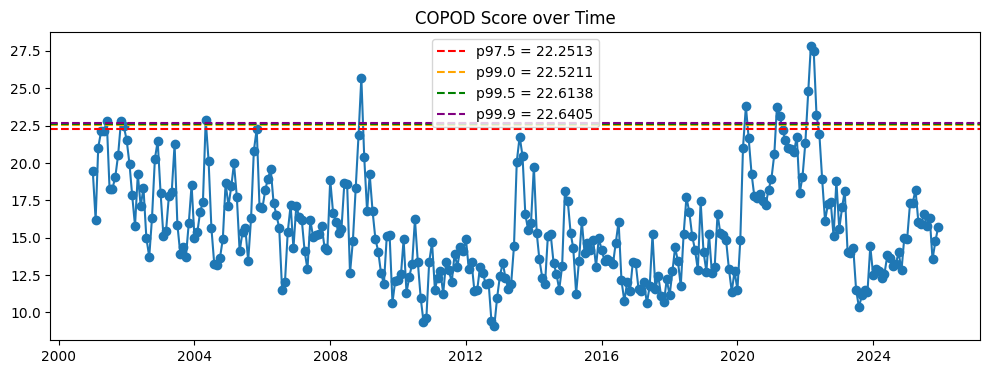

In [ ]:
colors = ['red', 'orange', 'green', 'purple']

plt.figure(figsize=(12,4))
plt.plot(X_scores.index, X_scores['copod_score'], marker='o')

for (p, th), c in zip(thrs.items(), colors):
    plt.axhline(
        th,
        linestyle='--',
        color=c,
        linewidth=1.5,
        label=f'p{p} = {th:.4f}'
    )

plt.legend()
plt.title("COPOD Score over Time")
plt.show()

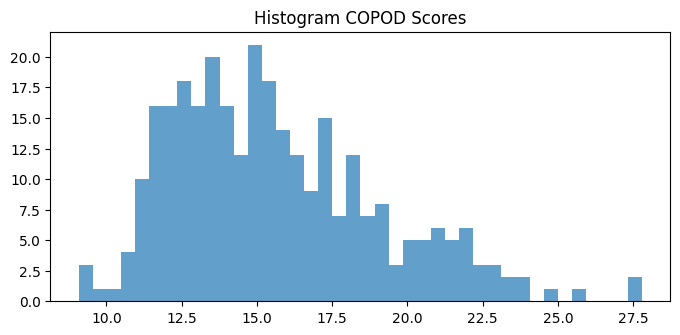

In [ ]:
plt.figure(figsize=(8,3.5))
plt.hist(X_scores['copod_score'], bins=40, alpha=0.7)
plt.title("Histogram COPOD Scores")
plt.show()

In [ ]:
s = X_scores['copod_score'].copy()

mean_s = np.mean(s)
std_s = np.std(s)

tau_z = mean_s + 3 * std_s
alpha_z = np.mean(s > tau_z)

print("Natural alpha (Z):", alpha_z)

Natural alpha (Z): 0.006666666666666667


In [ ]:
q1 = np.percentile(s, 25)
q3 = np.percentile(s, 75)
iqr = q3 - q1

tau_iqr = q3 + 1.5 * iqr
alpha_iqr = np.mean(s > tau_iqr)

print("Natural alpha (IQR):", alpha_iqr)

Natural alpha (IQR): 0.013333333333333334


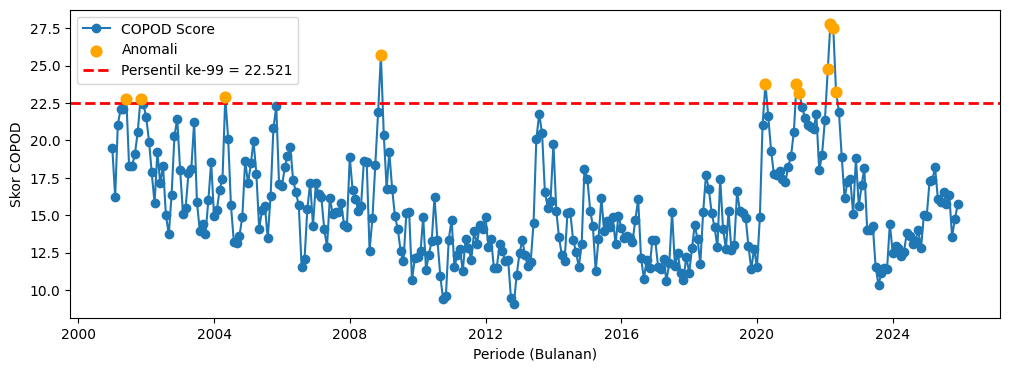

In [ ]:
thr_99 = np.percentile(train_scores, 99)
X_scores['is_anomaly_99'] = (X_scores['copod_score'] >= thr_99).astype(int)

plt.figure(figsize=(12,4))

plt.plot(X_scores.index,
         X_scores['copod_score'],
         marker='o',
         linestyle='-',
         label='COPOD Score')

plt.scatter(
    X_scores.index[X_scores['is_anomaly_99'] == 1],
    X_scores.loc[X_scores['is_anomaly_99'] == 1, 'copod_score'],
    color='orange',
    s=60,
    zorder=5,
    label='Anomali'
)

plt.axhline(
    thr_99,
    linestyle='--',
    color='red',
    linewidth=2,
    label=f'Persentil ke-99 = {thr_99:.3f}'
)

plt.legend()
plt.xlabel("Periode (Bulanan)")
plt.ylabel("Skor COPOD")
plt.show()

In [ ]:
thr_99 = np.percentile(train_scores, 99)
X_scores['is_anomaly_99'] = (X_scores['copod_score'] >= thr_99).astype(int)
anomalies_99 = X_scores[X_scores['copod_score'] >= thr_99].copy()
anomalies_99

,log1p_wisatawan,lag1_wisatawan,lag12_wisatawan,mom_wisatawan,inflasi,lag1_inflasi,lag6_inflasi,fx_return,lag1_fx_return,lag2_fx_return,sin_month,cos_month,copod_score,anomaly_p97_5,anomaly_p99_0,anomaly_p99_5,anomaly_p99_9,is_anomaly_99
period,,,,,,,,,,,,,,,,,,
2001-06-01,13.070076,13.026425,12.958144,0.044618,1.67,1.13,1.94,0.000178,-0.001653,0.103826,1.224647e-16,-1.000000e+00,22.793530,1,1,1,1,1
2001-11-01,12.870666,12.876770,12.994316,-0.006085,1.71,0.68,1.13,-0.002389,0.076041,0.091065,-5.000000e-01,8.660254e-01,22.786100,1,1,1,1,1
2004-05-01,12.982625,12.857601,12.502318,0.133177,0.88,0.97,1.01,0.066020,0.009275,0.023082,5.000000e-01,-8.660254e-01,22.875235,1,1,1,1,1
2008-12-01,13.321957,13.169558,13.159075,0.164625,-0.04,0.12,2.46,-0.134606,0.146867,0.150711,-2.449294e-16,1.000000e+00,25.710932,1,1,1,1,1
2020-04-01,11.970774,13.094285,14.057854,-0.674865,0.08,0.10,0.02,-0.070470,0.132979,0.047822,8.660254e-01,-5.000000e-01,23.788699,1,1,1,1,1
2021-03-01,11.695080,11.569202,13.094285,0.134146,0.08,0.10,-0.05,0.018841,0.021824,0.013674,1.000000e+00,6.123234e-17,23.753776,1,1,1,1,1
2021-04-01,11.632990,11.695080,11.970774,-0.060202,0.13,0.08,0.07,-0.011383,0.018841,0.021824,8.660254e-01,-5.000000e-01,23.169422,1,1,1,1,1
2022-02-01,11.563581,11.711604,11.569202,-0.137590,-0.02,0.56,0.03,-0.003301,0.006726,-0.006406,8.660254e-01,5.000000e-01,24.795906,1,1,1,1,1
2022-03-01,11.863639,11.563581,11.695080,0.349941,0.66,-0.02,-0.04,-0.000468,-0.003301,0.006726,1.000000e+00,6.123234e-17,27.804069,1,1,1,1,1


In [ ]:
top = anomalies_99.sort_values('copod_score', ascending=False)
display(top[['copod_score']])

,copod_score
period,
2022-03-01,27.804069
2022-04-01,27.507134
2008-12-01,25.710932
2022-02-01,24.795906
2020-04-01,23.788699
2021-03-01,23.753776
2022-05-01,23.232726
2021-04-01,23.169422
2004-05-01,22.875235


# **E. Kontribusi Fitur**

In [ ]:
def compute_u_from_train(train_ser, target_vals):
    train_vals = np.sort(train_ser)
    n = len(train_vals)
    counts = np.searchsorted(train_vals, target_vals, side='right')
    u = (counts + 1) / (n + 1)
    return u

train_skew = X_train.skew()
contrib = pd.DataFrame(index=X.index, columns=feature_cols, dtype=float)
eps = 1e-12
for col in feature_cols:
    u_vals = compute_u_from_train(X_train[col].values, X[col].values)
    left = -np.log(np.clip(u_vals, eps, 1.0))
    right = -np.log(np.clip(1.0 - u_vals, eps, 1.0))
    contrib[col] = right if train_skew[col] >= 0 else left

contrib['total_contrib'] = contrib.sum(axis=1)
contrib['copod_score'] = X_scores['copod_score']
contrib.to_csv(f"{SAVE_PREFIX}_contributions.csv")

In [ ]:
freq = contrib[feature_cols].idxmax(axis=1).value_counts().rename_axis('feature').reset_index(name='count')
print("Frekuensi fitur penyebab anomali:")
display(freq)

Frekuensi fitur penyebab anomali:


,feature,count
0,sin_month,49
1,lag2_fx_return,30
2,lag1_inflasi,28
3,mom_wisatawan,26
4,lag1_wisatawan,26
5,lag1_fx_return,24
6,lag12_wisatawan,23
7,inflasi,22
8,fx_return,21
9,lag6_inflasi,17
